<a href="https://colab.research.google.com/github/Jaffar-Kazmi/OCSS-Augmentation-Benchmark/blob/main/experiments/13_vit_base_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi
!pip install -q timm kaggle

Mon Sep 28 10:35:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3f4b8b004a4cc1a5431396fdd5d2d3eb"

!pip install -q -U kaggle
!kaggle kernels output syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb -p /content/nb1
!kaggle kernels output syedjaffarrazakazmi/02-piyarathne-train-test-split-ipynb -p /content/nb2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.1 MB/s eta 0:00:00
Output file downloaded to /content/nb1/piyarathne/annotations_fixed.json
Output file downloaded to /content/nb1/piyarathne/images/C-10-12-5.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-2-7.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-3-6.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-4-3.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-5-4.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-6-2.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-10-7-1.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-11-12-6.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-11-4-1.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-11-5-2.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-11-6-3.jpg
Output file downloaded to /content/nb1/piyarathne/images/C-11-6-4.jpg
Outpu

In [3]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
CONFIG = {
    # --- paths (Colab) ---
    "split_csv": Path("/content/nb2/piyarathne_split.csv"),
    "image_dir": Path("/content/nb1/piyarathne/images"),

    "filename_col": "file_name",
    "label_col": "Category",
    "fold_col": "fold",
    "n_folds": 5,

    # --- this run's identity ---
    "config_name": "config10_vit_b16_combined",

    # --- model ---
    "backbone": "vit_base_patch16_224",
    "pretrained": True,
    "num_classes": 4,
    "image_size": 224,

    # --- training ---
    "batch_size": 32,
    "epochs": 30,
    "lr": 5e-5,
    "weight_decay": 1e-4,
    "patience": 5,
    "num_workers": 2,

    # --- imbalance handling ---
    "use_class_weights": True,

    # --- output directories ---
    "checkpoint_dir": Path("/content/work/checkpoints"),
    "results_log": Path("/content/work/results/results_log.csv"),
    "oof_preds_path": Path("/content/work/results/oof_predictions.csv"),
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_log"].parent.mkdir(parents=True, exist_ok=True)

# Fixed label order, so class indices are identical across every fold and every config
CLASS_NAMES = ["Healthy", "Benign", "OPMD", "OCA"]
LABEL2IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX2LABEL = {i: name for name, i in LABEL2IDX.items()}

print("image_dir exists:", CONFIG["image_dir"].exists(), "| split_csv exists:", CONFIG["split_csv"].exists())

df = pd.read_csv(CONFIG["split_csv"])
df["image_path"] = df[CONFIG["filename_col"]].apply(lambda f: str(CONFIG["image_dir"] / f))
df["label"] = df[CONFIG["label_col"]].map(LABEL2IDX)

assert df["label"].isna().sum() == 0, "Some Category values didn't map to a known class"

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].map(IDX2LABEL).value_counts())
print("\nFold distribution:")
print(pd.crosstab(df["fold"], df["label"].map(IDX2LABEL)))

image_dir exists: True | split_csv exists: True
Shape: (3000, 16)

Class distribution:
label
OPMD       1394
Benign      748
Healthy     729
OCA         129
Name: count, dtype: int64

Fold distribution:
label  Benign  Healthy  OCA  OPMD
fold                             
0         164      119   14   271
1         127      153   40   281
2         134      134   21   305
3         167      168   31   269
4         156      155   23   268


In [5]:
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class OCADataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["image_path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

# Config 8: Config 4 transforms + focal loss (loss change lives in Cell 4)
train_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=15, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Image tensor shape:", sample_img.shape)
print("Label:", sample_label, "->", IDX2LABEL[sample_label])

Image tensor shape: torch.Size([3, 224, 224])
Label: 2 -> OPMD


In [6]:
import timm

def build_model(backbone, num_classes, pretrained=True):
    model = timm.create_model(backbone, pretrained=pretrained, num_classes=num_classes)
    return model.to(device)

model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
print(f"Built {CONFIG['backbone']} with {sum(p.numel() for p in model.parameters()):,} params")

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Built vit_base_patch16_224 with 85,801,732 params


In [7]:
def get_class_weights(train_df, num_classes):
    counts = train_df["label"].value_counts().sort_index()
    weights = (1.0 / counts).reindex(range(num_classes)).fillna(0)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights.values, dtype=torch.float32).to(device)

def build_criterion(train_df, config):
    if config["use_class_weights"]:
        class_weights = get_class_weights(train_df, config["num_classes"])
    else:
        class_weights = None
    return nn.CrossEntropyLoss(weight=class_weights)

def build_optimizer_and_scheduler(model, config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    return optimizer, scheduler

# Quick check on the full dataset's weights, just to see the scale
_test_weights = get_class_weights(df, CONFIG["num_classes"])
print("Class weights (Healthy, Benign, OPMD, OCA):", _test_weights.cpu().numpy())

Class weights (Healthy, Benign, OPMD, OCA): [0.4908748  0.47840607 0.2567057  2.7740135 ]


In [8]:
from sklearn.metrics import accuracy_score, f1_score

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    torch.set_grad_enabled(is_train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, config, fold_idx):
    best_val_f1 = -1
    epochs_no_improve = 0
    history = []
    ckpt_path = config["checkpoint_dir"] / f"{config['config_name']}_fold{fold_idx}_best.pt"

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d} | train_loss {train_loss:.4f} f1 {train_f1:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | {elapsed:.1f}s")

        history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                         "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config["patience"]:
                print(f"  Early stopping at epoch {epoch}")
                break

    return history, best_val_f1, ckpt_path

In [9]:
from PIL import Image
import os

CACHE_DIR = Path("/content/work/cache_256")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_SIZE = 256  # slightly larger than the 224 training size, leaves room for random-crop augmentation configs later

def build_cache(df, cache_dir, cache_size):
    unique_paths = df["image_path"].unique()
    print(f"Caching {len(unique_paths)} unique images to {cache_dir} at {cache_size}x{cache_size}...")
    t0 = time.time()
    for i, src_path in enumerate(unique_paths):
        dst_path = cache_dir / Path(src_path).name
        if dst_path.exists():
            continue
        img = Image.open(src_path).convert("RGB")
        img = img.resize((cache_size, cache_size), Image.BILINEAR)
        img.save(dst_path, quality=90)
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(unique_paths)} done, {time.time()-t0:.0f}s elapsed")
    print(f"Cache built in {time.time()-t0:.0f}s")

build_cache(df, CACHE_DIR, CACHE_SIZE)

# Point image_path at the cached, pre-resized copies instead of the originals
df["image_path"] = df["file_name"].apply(lambda f: str(CACHE_DIR / f))

# Re-verify one image loads correctly from cache
sample_img, sample_label = OCADataset(df, eval_transform)[0]
print("Cached image tensor shape:", sample_img.shape)

Caching 3000 unique images to /kaggle/working/cache_256 at 256x256...
  500/3000 done, 82s elapsed
  1000/3000 done, 176s elapsed
  1500/3000 done, 238s elapsed
  2000/3000 done, 297s elapsed
  2500/3000 done, 369s elapsed
  3000/3000 done, 427s elapsed
Cache built in 427s
Cached image tensor shape: torch.Size([3, 224, 224])


In [10]:
oof_preds = np.full(len(df), -1, dtype=int)
oof_probs = np.zeros((len(df), CONFIG["num_classes"]), dtype=float)
fold_val_f1s = []
fold_histories = {}
fold_ckpt_paths = {}

for fold_idx in range(CONFIG["n_folds"]):
    print(f"\n{'='*60}\nFold {fold_idx}\n{'='*60}")

    train_df = df[df["fold"] != fold_idx].reset_index(drop=True)
    val_df = df[df["fold"] == fold_idx].reset_index(drop=True)
    val_indices = df.index[df["fold"] == fold_idx].to_numpy()

    train_ds = OCADataset(train_df, train_transform)
    val_ds = OCADataset(val_df, eval_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)

    # Fresh model, criterion, optimizer, scheduler every fold, no carryover between folds
    model = build_model(CONFIG["backbone"], CONFIG["num_classes"], CONFIG["pretrained"])
    criterion = build_criterion(train_df, CONFIG)
    optimizer, scheduler = build_optimizer_and_scheduler(model, CONFIG)

    history, best_val_f1, ckpt_path = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, CONFIG, fold_idx
    )
    fold_histories[fold_idx] = history
    fold_val_f1s.append(best_val_f1)
    fold_ckpt_paths[fold_idx] = ckpt_path

    # Reload best checkpoint for this fold, generate OOF predictions on its val split
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    fold_probs = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            fold_probs.append(probs.cpu().numpy())
    fold_probs = np.concatenate(fold_probs, axis=0)

    oof_probs[val_indices] = fold_probs
    oof_preds[val_indices] = fold_probs.argmax(axis=1)

    print(f"Fold {fold_idx} best val macro-F1: {best_val_f1:.4f}")

assert (oof_preds != -1).all(), "Some rows never got an OOF prediction, check fold assignment"
print(f"\nPer-fold val macro-F1: mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f}")
print("Per-fold scores:", [round(f, 4) for f in fold_val_f1s])


Fold 0
  Epoch 01 | train_loss 1.4552 f1 0.2763 | val_loss 1.3928 acc 0.1637 f1 0.1795 | 104.4s
  Epoch 02 | train_loss 1.2393 f1 0.3573 | val_loss 1.2017 acc 0.4595 f1 0.3601 | 101.6s
  Epoch 03 | train_loss 1.0712 f1 0.4650 | val_loss 1.0739 acc 0.5387 f1 0.4447 | 101.6s
  Epoch 04 | train_loss 0.8545 f1 0.5738 | val_loss 1.1277 acc 0.5370 f1 0.4720 | 101.4s
  Epoch 05 | train_loss 0.7775 f1 0.6179 | val_loss 1.2272 acc 0.4982 f1 0.4408 | 101.3s
  Epoch 06 | train_loss 0.6051 f1 0.7047 | val_loss 1.1227 acc 0.5933 f1 0.5484 | 101.1s
  Epoch 07 | train_loss 0.4692 f1 0.7858 | val_loss 1.5313 acc 0.5088 f1 0.4236 | 101.5s
  Epoch 08 | train_loss 0.4235 f1 0.8007 | val_loss 1.5227 acc 0.5687 f1 0.4940 | 101.3s
  Epoch 09 | train_loss 0.3487 f1 0.8393 | val_loss 1.7326 acc 0.5317 f1 0.4431 | 101.6s
  Epoch 10 | train_loss 0.1885 f1 0.9247 | val_loss 1.6324 acc 0.5634 f1 0.4674 | 101.1s
  Epoch 11 | train_loss 0.1579 f1 0.9360 | val_loss 1.9399 acc 0.5581 f1 0.4756 | 101.4s
  Early stopp

In [11]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

oof_acc = accuracy_score(df["label"], oof_preds)
oof_macro_f1 = f1_score(df["label"], oof_preds, average="macro")
precision, recall, f1_per_class, support = precision_recall_fscore_support(
    df["label"], oof_preds, labels=list(range(CONFIG["num_classes"]))
)
cm = confusion_matrix(df["label"], oof_preds, labels=list(range(CONFIG["num_classes"])))

print(f"Pooled OOF accuracy: {oof_acc:.4f}")
print(f"Pooled OOF macro-F1: {oof_macro_f1:.4f}")
print(f"\nPer-fold mean {np.mean(fold_val_f1s):.4f}, std {np.std(fold_val_f1s):.4f} (secondary stability check)")

print("\nPer-class metrics (pooled OOF):")
for c in range(CONFIG["num_classes"]):
    print(f"  {IDX2LABEL[c]:>8s}: precision {precision[c]:.4f}, recall {recall[c]:.4f}, "
          f"f1 {f1_per_class[c]:.4f}, support {support[c]}")

print("\nConfusion matrix (rows=true, cols=pred):")
print("        ", "  ".join(f"{IDX2LABEL[c]:>8s}" for c in range(CONFIG["num_classes"])))
for i, row in enumerate(cm):
    print(f"{IDX2LABEL[i]:>8s}", "  ".join(f"{v:8d}" for v in row))

# --- Log this config's result to the shared comparison table ---
result_row = {
    "config_name": CONFIG["config_name"],
    "backbone": CONFIG["backbone"],
    "oof_accuracy": oof_acc,
    "oof_macro_f1": oof_macro_f1,
    "per_fold_f1_mean": np.mean(fold_val_f1s),
    "per_fold_f1_std": np.std(fold_val_f1s),
}
for c in range(CONFIG["num_classes"]):
    result_row[f"{IDX2LABEL[c]}_precision"] = precision[c]
    result_row[f"{IDX2LABEL[c]}_recall"] = recall[c]
    result_row[f"{IDX2LABEL[c]}_f1"] = f1_per_class[c]

if CONFIG["results_log"].exists():
    log_df = pd.read_csv(CONFIG["results_log"])
    log_df = pd.concat([log_df, pd.DataFrame([result_row])], ignore_index=True)
else:
    log_df = pd.DataFrame([result_row])
log_df.to_csv(CONFIG["results_log"], index=False)

# --- Save the raw OOF predictions too, useful later for error analysis or ensembling ---
oof_df = df[["file_name", "patient_id", "fold", "label"]].copy()
oof_df["label_name"] = oof_df["label"].map(IDX2LABEL)
oof_df["pred"] = oof_preds
oof_df["pred_name"] = oof_df["pred"].map(IDX2LABEL)
for c in range(CONFIG["num_classes"]):
    oof_df[f"prob_{IDX2LABEL[c]}"] = oof_probs[:, c]
oof_df.to_csv(CONFIG["oof_preds_path"], index=False)

print(f"\nLogged to {CONFIG['results_log']}")
print(f"OOF predictions saved to {CONFIG['oof_preds_path']}")
log_df

Pooled OOF accuracy: 0.6113
Pooled OOF macro-F1: 0.5570

Per-fold mean 0.5458, std 0.0124 (secondary stability check)

Per-class metrics (pooled OOF):
   Healthy: precision 0.6761, recall 0.5871, f1 0.6285, support 729
    Benign: precision 0.4806, recall 0.5789, f1 0.5252, support 748
      OPMD: precision 0.6922, recall 0.6600, f1 0.6757, support 1394
       OCA: precision 0.3869, recall 0.4109, f1 0.3985, support 129

Confusion matrix (rows=true, cols=pred):
          Healthy    Benign      OPMD       OCA
 Healthy      428       133       162         6
  Benign       69       433       209        37
    OPMD      136       297       920        41
     OCA        0        38        38        53

Logged to /content/work/results/results_log.csv
OOF predictions saved to /content/work/results/oof_predictions.csv


,config_name,backbone,oof_accuracy,oof_macro_f1,per_fold_f1_mean,per_fold_f1_std,Healthy_precision,Healthy_recall,Healthy_f1,Benign_precision,Benign_recall,Benign_f1,OPMD_precision,OPMD_recall,OPMD_f1,OCA_precision,OCA_recall,OCA_f1
0,config10_vit_b16_combined,vit_base_patch16_224,0.611333,0.556969,0.545767,0.012372,0.676145,0.587106,0.628488,0.480577,0.578877,0.525167,0.69225,0.659971,0.675725,0.386861,0.410853,0.398496


OCA images: 129 total, 53 correct, 76 misclassified

Where the misclassified OCA images ended up:
pred_name
OPMD      38
Benign    38
Name: count, dtype: int64

Top 10 most confidently wrong OCA predictions:
   file_name Clinical Diagnosis pred_name  confidence_in_wrong_pred     prob_OCA
R-252-05.jpg        Oral Cancer    Benign                  0.999721 3.504182e-07
R-252-03.jpg        Oral Cancer    Benign                  0.999467 9.445156e-06
R-252-01.jpg        Oral Cancer    Benign                  0.999088 2.810959e-05
R-252-06.jpg        Oral Cancer    Benign                  0.994240 2.569708e-04
S-181-01.jpg        Oral Cancer      OPMD                  0.994162 3.452789e-03
R-252-02.jpg        Oral Cancer    Benign                  0.991421 1.924857e-03
 R-10-01.jpg        Oral Cancer      OPMD                  0.986466 8.789602e-05
 S-68-02.jpg Verrucus Carcinoma      OPMD                  0.979721 2.400434e-03
 S-87-01.jpg        Oral Cancer    Benign                  0.97

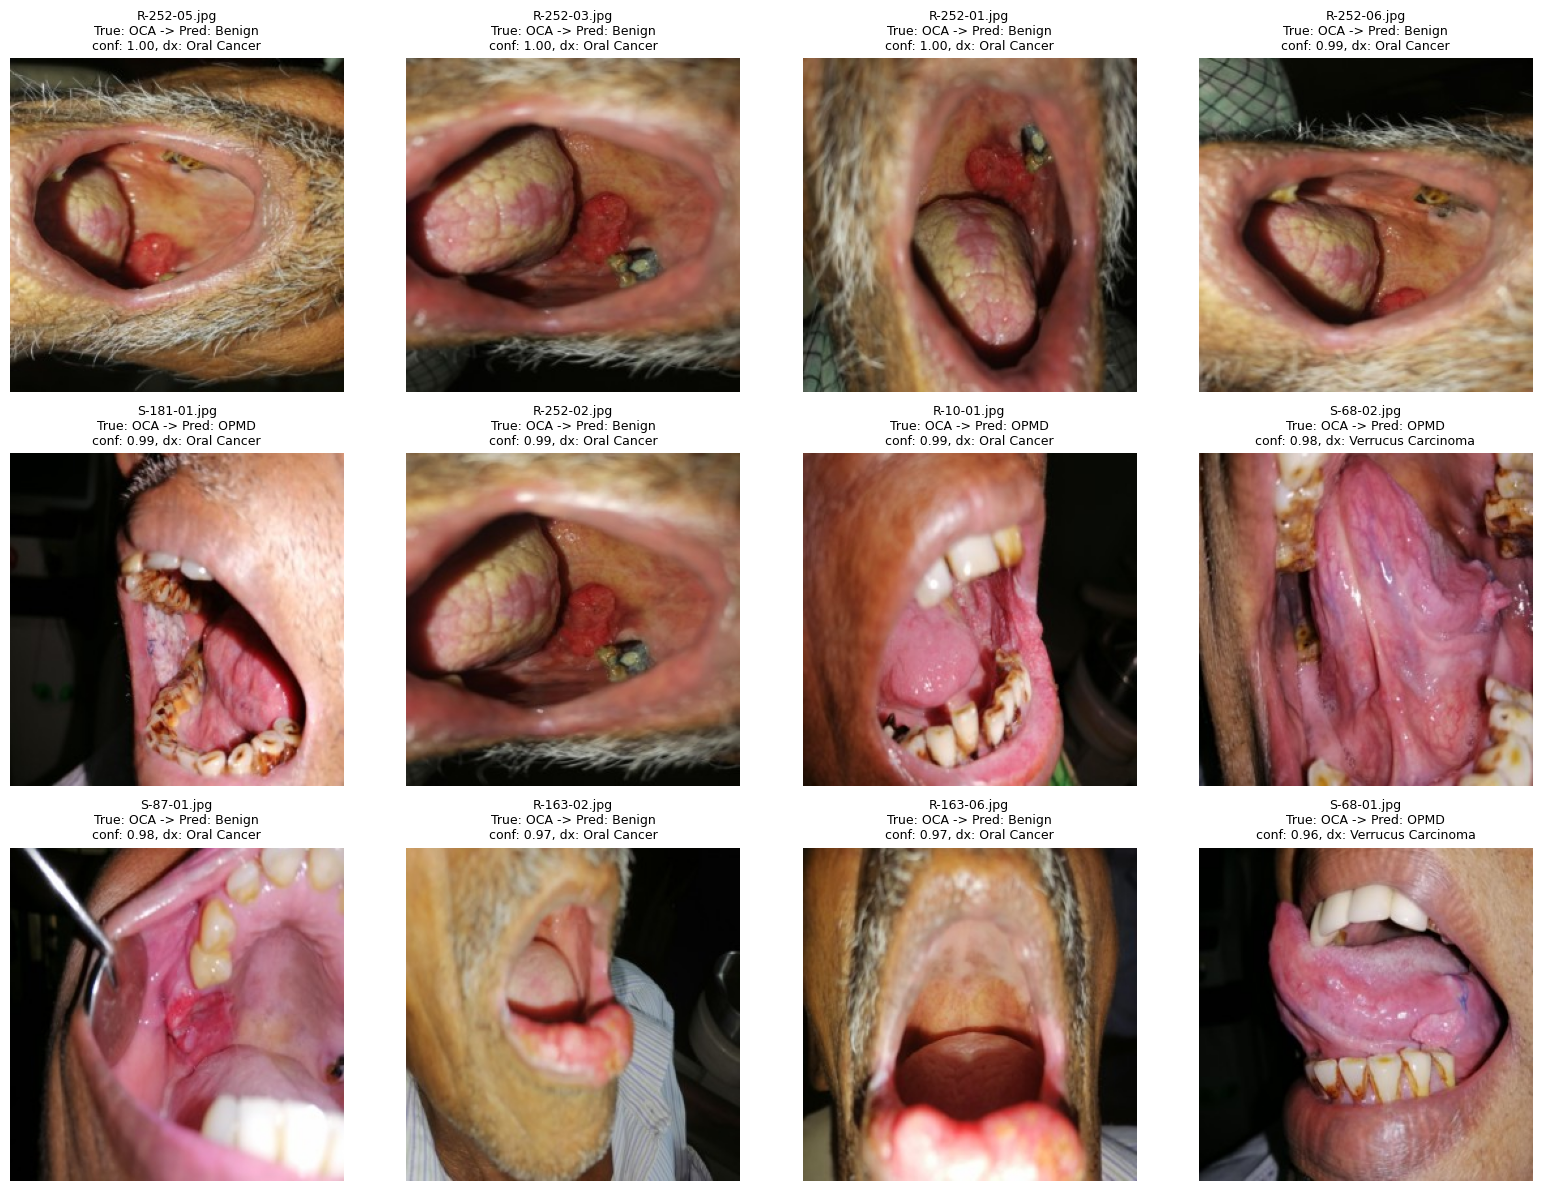

In [12]:
import matplotlib.pyplot as plt

oof_df = pd.read_csv(CONFIG["oof_preds_path"])

oca_true = oof_df[oof_df["label_name"] == "OCA"].copy()
oca_correct = oca_true[oca_true["pred_name"] == "OCA"]
oca_wrong = oca_true[oca_true["pred_name"] != "OCA"]

print(f"OCA images: {len(oca_true)} total, {len(oca_correct)} correct, {len(oca_wrong)} misclassified")
print("\nWhere the misclassified OCA images ended up:")
print(oca_wrong["pred_name"].value_counts())

# Merge back patient_id and clinical diagnosis for context, if available in df
oca_wrong = oca_wrong.merge(
    df[["file_name", "Clinical Diagnosis"]].drop_duplicates("file_name"),
    on="file_name", how="left"
)

# Sort by model confidence in its (wrong) prediction, highest confidence wrong answers are most interesting
oca_wrong["confidence_in_wrong_pred"] = oca_wrong.apply(
    lambda row: row[f"prob_{row['pred_name']}"], axis=1
)
oca_wrong = oca_wrong.sort_values("confidence_in_wrong_pred", ascending=False)

print("\nTop 10 most confidently wrong OCA predictions:")
print(oca_wrong[["file_name", "Clinical Diagnosis", "pred_name", "confidence_in_wrong_pred", "prob_OCA"]].head(10).to_string(index=False))

# Visualize the 12 most confidently wrong ones
n_show = min(12, len(oca_wrong))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flat, oca_wrong.head(n_show).iterrows()):
    img_path = CACHE_DIR / row["file_name"]
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{row['file_name']}\nTrue: OCA -> Pred: {row['pred_name']}\n"
                 f"conf: {row['confidence_in_wrong_pred']:.2f}, dx: {row['Clinical Diagnosis']}",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()